# The Multilayer Perceptron Model

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from rice_ml.Supervised_Learning.multilayer_perceptron_class import MultiLayerPerceptron
from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

# Import sklearn's plot_confusion_matrix for visualization
from sklearn.metrics import confusion_matrix

# Set the Seaborn theme
sns.set_theme()

# Reading in the Spam Email Dataset
df = pd.read_csv("../datasets/spam_email_dataset.csv")
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


# Dataset Exploration

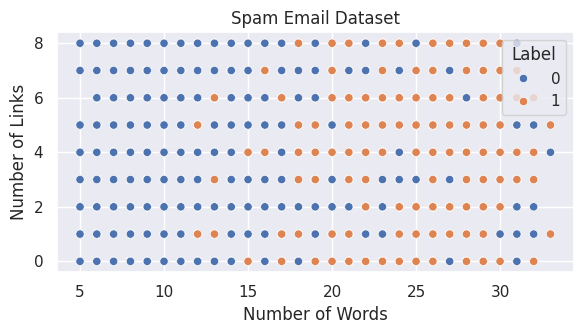

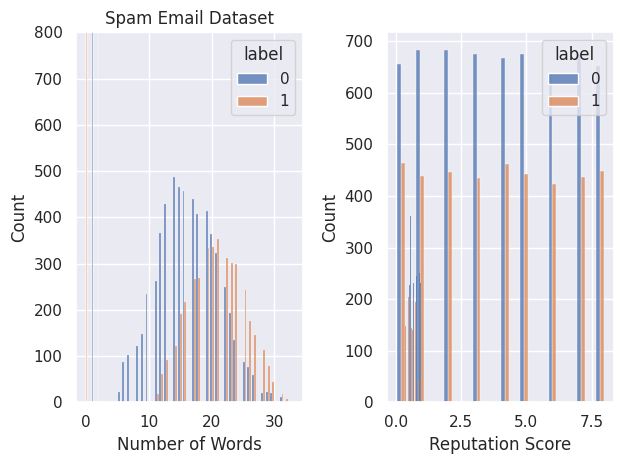

Missing Values per Column:
|                         |   0 |
|:------------------------|----:|
| email_id                |   0 |
| subject                 |   0 |
| email_text              |   0 |
| num_words               |   0 |
| num_characters          |   0 |
| num_exclamation_marks   |   0 |
| num_links               |   0 |
| has_suspicious_link     |   0 |
| num_attachments         |   0 |
| has_attachment          |   0 |
| sender_email            |   0 |
| sender_domain           |   0 |
| sender_reputation_score |   0 |
| email_hour              |   0 |
| email_day_of_week       |   0 |
| is_weekend              |   0 |
| num_recipients          |   0 |
| contains_money_terms    |   0 |
| contains_urgency_terms  |   0 |
| label                   |   0 |


In [ ]:
# Visualize the dataset 

# Scatter plot of num_words vs num_links colored by label
plt.figure(figsize=(6, 3.5))
sns.scatterplot(data=df, x="num_words", y="num_links", hue="label")
plt.title("Spam Email Dataset")
plt.xlabel("Number of Words")
plt.ylabel("Number of Links")
plt.legend(title="Label", loc="upper right")
plt.tight_layout()
plt.show()

# Histograms of num_attachments and num_links colored by label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="num_attachments", hue="label", multiple="dodge", shrink=0.8)
plt.title("Spam Email Dataset")
plt.xlabel("Number of Attachments")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="num_links", hue="label", multiple="dodge", shrink=0.8)
plt.xlabel("Number of Links")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="num_words", hue="label", multiple="dodge", shrink=0.8)
plt.ylim(0, 800)
plt.xlabel("Number of Words")
plt.ylabel("Count")
# Histograms of num_words and sender_reputation_score colored by label
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="sender_reputation_score", hue="label", multiple="dodge", shrink=0.8)
plt.xlabel("Reputation Score")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Missing values in the dataset
print("Missing Values per Column:")
print(df.isnull().sum().to_markdown())


# Preprocessing

In [3]:
# Selecting features and target variable
features = ["num_words", "num_links", "num_attachments", "sender_reputation_score"]
target = "label"
X = df[features].values
y = df[target].values

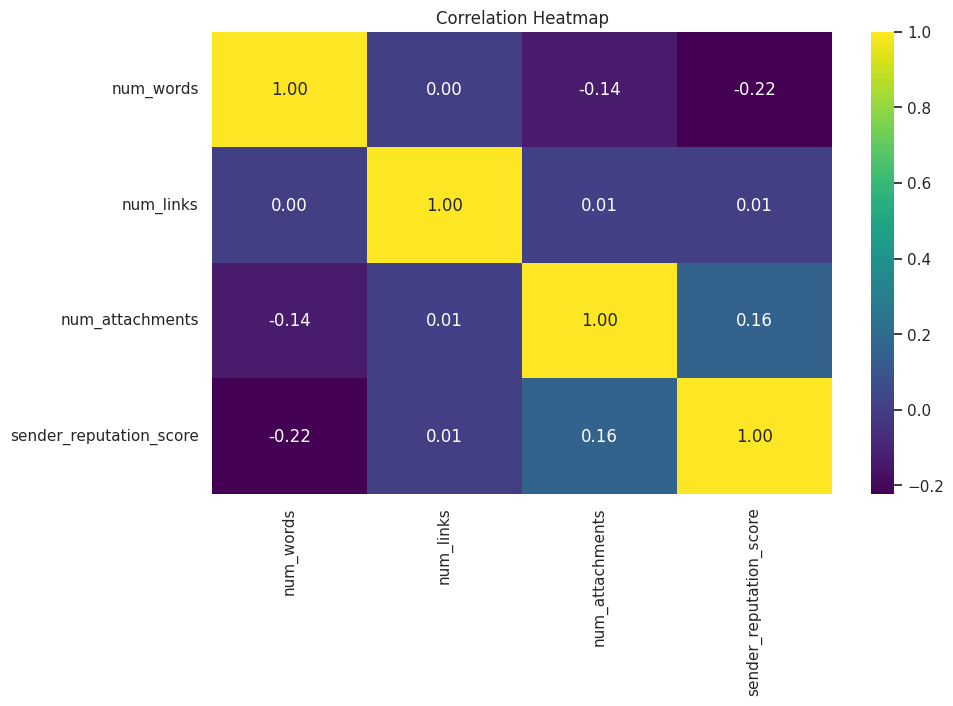

In [4]:
# Correlation heatmap of the features
corr_map = df[features].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_map, annot=True, cmap='viridis', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
# Selecting only the two most correlated features for visualization
X_vis = df[["num_words", "num_links"]].values
y_vis = df[target].values

In [5]:
# Standardize the features
X_vis = standardize(X_vis)
# Split the data into training and testing sets
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y_vis, test_size=0.2, random_state=42)
# Train a simple MLP on the two most correlated features for visualization
mlp_vis = MultiLayerPerceptron(hidden_layer_sizes=[5], eta=0.01, epochs=1000, random_state=42)
mlp_vis.train(X_train_vis, y_train_vis)
print("Training complete for visualization MLP.")

Training complete for visualization MLP.


# Prediction and Evaluation

Evaluation results for the MLP trained on the two most correlated features (num_words and num_links):
Test Accuracy for Visualization MLP: 0.6390
Classification Report for Visualization MLP:
{'classification_error': 0.361, 'precision': 0.7777777777777778, 'confusion_matrix': array([[1180,   28],
       [ 694,   98]])}


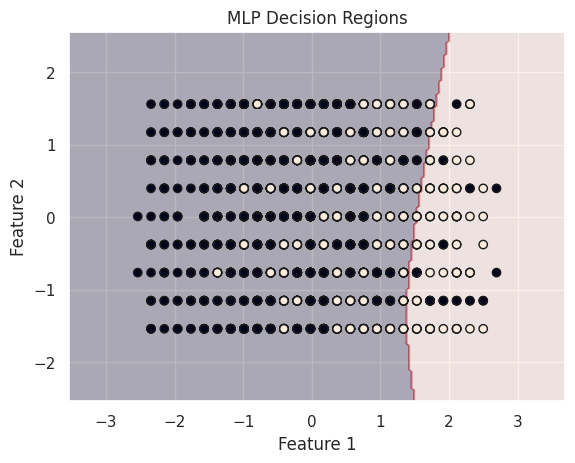

In [7]:
# Generate predictions on the test set for visualization
y_pred_vis = mlp_vis.predict(X_test_vis)
# Evaluate the performance of the MLP on the test set for visualization
postprocessor_vis = PostProcessor()
accuracy_vis = postprocessor_vis.accuracy(y_test_vis, y_pred_vis)
report = postprocessor_vis.classification_metrics(y_test_vis, y_pred_vis)
print(f"Evaluation results for the MLP trained on the two most correlated features (num_words and num_links):")
print(f"Test Accuracy for Visualization MLP: {accuracy_vis:.4f}")
print("Classification Report for Visualization MLP:")
print(report)

# Plot Decision Boundary for Visualization MLP
mlp_vis.plot_decision_regions(X_test_vis, y_test_vis)